In [1]:
import subprocess
from timing_parser import parse_timing_output

MAX_SECONDS = 10
STEP_SIZE = 20000000
MAX_NUMBER_COUNT = 1000000000
BIT_COUNTS_TO_TEST = [1, 2, 4, 8, 16]

timings = {}
for bits in BIT_COUNTS_TO_TEST:
    for numberCount in range(50000000, MAX_NUMBER_COUNT, STEP_SIZE):

        try:
            output = subprocess.check_output(["../problem_4", f"{numberCount} {bits}"], timeout=300)
            result = parse_timing_output(output.decode())
            print(f"{bits},{numberCount} done in {result[len(result)-1][1]:.2f}s")
            if result[len(result)-1][1] > MAX_SECONDS:
                print(f"greater 10s -> next bits")
                break
            timings[(bits, numberCount)] = result
        except subprocess.TimeoutExpired as e:
            print(f"Timeout -> next bits")
            break

1,50000000 done in 0.39s
1,70000000 done in 0.47s
1,90000000 done in 0.55s
1,110000000 done in 0.64s
1,130000000 done in 0.82s
1,150000000 done in 0.94s
1,170000000 done in 1.50s
1,190000000 done in 1.58s
1,210000000 done in 1.99s
1,230000000 done in 2.03s
1,250000000 done in 2.06s
1,270000000 done in 3.10s
1,290000000 done in 2.52s
1,310000000 done in 3.35s
1,330000000 done in 2.99s
1,350000000 done in 4.18s
1,370000000 done in 5.11s
1,390000000 done in 4.24s
1,410000000 done in 5.21s
1,430000000 done in 5.94s
1,450000000 done in 11.66s
greater 10s -> next bits
2,50000000 done in 0.29s
2,70000000 done in 0.38s
2,90000000 done in 0.49s
2,110000000 done in 0.61s
2,130000000 done in 0.70s
2,150000000 done in 0.79s
2,170000000 done in 0.92s
2,190000000 done in 1.02s
2,210000000 done in 1.13s
2,230000000 done in 1.26s
2,250000000 done in 1.36s
2,270000000 done in 1.47s
2,290000000 done in 1.60s
2,310000000 done in 1.96s
2,330000000 done in 1.78s
2,350000000 done in 2.36s
2,370000000 done i

In [3]:
import csv

with open('timings_parallel.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['bits', 'numberCount', 'run_id', 'part1_time', 'part1_pct', 'part2_time', 'part2_pct', 'part3_time', 'part3_pct', 'avg_time'])
    
    for (bits, numberCount), runs in timings.items():
        for run_id, avg_time, parts in runs:
            row = [bits, numberCount, run_id if run_id is not None else 'avg']
            for t, pct in parts:
                row += [t, pct]
            while len(row) < 9:
                row += [None, None]
            row.append(avg_time)
            writer.writerow(row)

In [8]:
import csv

timings = {}

with open('timings_parallel.csv', 'r') as f:
    reader = csv.DictReader(f)
    for row in reader:
        bits = int(row['bits'])
        numberCount = int(row['numberCount'])
        run_id = None if row['run_id'] == 'avg' else int(row['run_id'])
        avg_time = float(row['avg_time']) if row['avg_time'] else None
        parts = []
        for i in range(1, 4):
            t = row.get(f'part{i}_time')
            pct = row.get(f'part{i}_pct')
            if t and pct:
                parts.append((float(t), float(pct)))

        key = (bits, numberCount)
        if key not in timings:
            timings[key] = []
        timings[key].append((run_id, avg_time, parts))

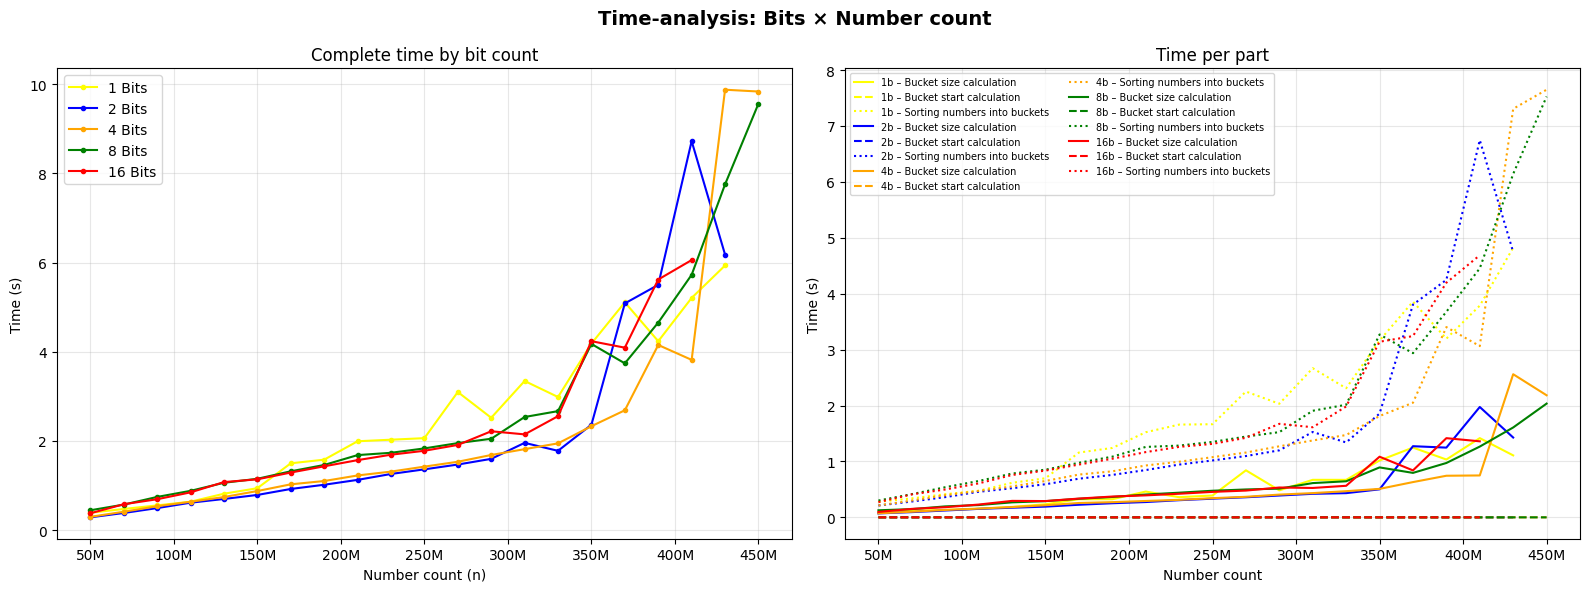

In [9]:
import matplotlib.pyplot as plt

colors = {1: 'yellow', 2: 'blue', 4: 'orange', 8: 'green', 16: 'red'}
part_labels = ['Bucket size calculation', 'Bucket start calculation', 'Sorting numbers into buckets']
part_styles = ['-', '--', ':']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax1 = axes[0]
ax2 = axes[1]

def get_avg_time(runs):
    """Aus der 'Average time taken:' Zeile"""
    return next((avg_time
                 for run_id, avg_time, parts in runs
                 if avg_time is not None), None)

def get_avg_parts(runs):
    """Aus der 'Average Time of the Runs:' Zeile"""
    return next((parts
                 for run_id, avg_time, parts in runs
                 if run_id is None and len(parts) > 0), None)

# Alle verfügbaren Werte direkt aus den Keys holen
all_bits = sorted(set(bits for bits, _ in timings.keys()))
all_counts = sorted(set(count for _, count in timings.keys()))

# --- Plot 1 ---
for bits in all_bits:
    xs, ys = [], []
    for numberCount in all_counts:
        result = timings.get((bits, numberCount))
        if result is None:
            continue
        avg_time = get_avg_time(result)
        if avg_time is not None:
            xs.append(numberCount)
            ys.append(avg_time)
    ax1.plot(xs, ys, label=f"{bits} Bits", color=colors.get(bits), marker='o', markersize=3)

ax1.set_title("Complete time by bit count")
ax1.set_xlabel("Number count (n)")
ax1.set_ylabel("Time (s)")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x / 1e6:.0f}M"))

for bits in all_bits:
    xs = []
    part_times = [[], [], []]
    for numberCount in all_counts:
        result = timings.get((bits, numberCount))
        if result is None:
            continue
        parts = get_avg_parts(result)
        if parts:
            xs.append(numberCount)
            for i, (t, _) in enumerate(parts):
                part_times[i].append(t)

    for i, (pt, style) in enumerate(zip(part_times, part_styles)):
        ax2.plot(xs, pt, label=f"{bits}b – {part_labels[i]}",
                 color=colors.get(bits), linestyle=style, linewidth=1.5)

ax2.set_title("Time per part")
ax2.set_xlabel("Number count")
ax2.set_ylabel("Time (s)")
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x / 1e6:.0f}M"))

plt.suptitle("Time-analysis: Bits × Number count", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()